# W2 Flow versus Muon Spectral Flow for a Homogeneous ReLU Model

This notebook generates `fig:gradflow-mlp-w2-vs-muon`. It follows the two-layer ReLU experiment of Peyr\'e's Muon dynamics paper, in a compact and variance-reduced form adapted to the book figures.

Particles are neurons $x=(u,v)\in \mathbb{R}\times\mathbb{R}^2$ and
$$
    \varphi(x,z)=u\,\max(\langle v,z\rangle,0), \qquad
    h_\alpha(z)=\int \varphi(x,z)\,d\alpha(x).
$$
The square loss defines a mean-field energy $f(\alpha)$. We compare two particle flows for the same empirical Wasserstein gradient matrix $G_X$:
$$
    \dot X=-G_X \qquad\text{and}\qquad
    \dot X=-\|G_X\|_*\,U V^\top,
    \quad G_X=U\Sigma V^\top .
$$
The first is the standard $W_2$ particle flow, while the second is the idealized Muon, or spectral-gauge, direction up to time rescaling.

The numerical experiment uses antithetic Gaussian samples for the data variable $z$, a shared initialization, and a small normalized Euler step. The intent is not to benchmark runtime, but to visualize how spectral normalization changes the collective direction followed by the neurons.


In [1]:
from pathlib import Path
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import BLUE, RED, GRAY, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
rng = np.random.default_rng(902)

NAME = "gradflow-mlp-w2-vs-muon"
out = ROOT / "latex" / "figures" / NAME
out.mkdir(parents=True, exist_ok=True)
out_pde = ROOT / "PDE4ML" / "figures" / NAME
out_pde.mkdir(parents=True, exist_ok=True)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)


## Mean-field ReLU teacher and spectral selectors

The displayed coordinate is the homogeneous projection $(|u|v_1,|u|v_2)$.  In this plane, teacher neurons define preferred rays, so one can see whether the flow concentrates mass in the right directions.


In [2]:
def relu(t):
    return np.maximum(t, 0.0)

def antithetic_gaussian(n_pairs, dim, rng):
    z = rng.normal(size=(n_pairs, dim))
    return np.vstack([z, -z])

def predict(X, z):
    u = X[:, 0]
    v = X[:, 1:3]
    return (u[:, None] * relu(v @ z.T)).mean(axis=0)

def empirical_risk(X, z, y):
    residual = predict(X, z) - y
    return 0.5 * float(np.mean(residual**2))

def first_variation_gradient(X, z, y):
    """Empirical Wasserstein gradient, i.e. n times the Euclidean gradient."""
    u = X[:, 0]
    v = X[:, 1:3]
    logits = v @ z.T
    R = relu(logits)
    residual = (u[:, None] * R).mean(axis=0) - y
    grad_u = R @ residual / len(z)
    active = (logits > 0).astype(float)
    grad_v = (active * residual[None, :]) @ z / len(z)
    grad_v *= u[:, None]
    return np.column_stack([grad_u, grad_v])

def spectral_selector(G, method):
    if method == "w2":
        return -G
    if method == "muon":
        U, S, Vt = np.linalg.svd(G, full_matrices=False)
        if S.sum() < 1e-14:
            return np.zeros_like(G)
        return -S.sum() * (U @ Vt)
    raise ValueError(method)

def transform_to_pq(X):
    X = np.nan_to_num(np.asarray(X), nan=0.0, posinf=0.0, neginf=0.0)
    return np.abs(X[:, 0:1]) * X[:, 1:3]

teacher_u = np.array([1.0, 1.0, -1.0])
teacher_angles = np.array([0.38, 2.42, 4.63])
teacher_v = np.column_stack([np.cos(teacher_angles), np.sin(teacher_angles)])
teacher = np.column_stack([teacher_u, teacher_v])
teacher_pq = transform_to_pq(teacher)

# Antithetic sampling reduces Monte-Carlo noise in the displayed risk curves.
z_train = antithetic_gaussian(700, 2, rng)
z_eval = antithetic_gaussian(1400, 2, rng)
y_train = predict(teacher, z_train)
y_eval = predict(teacher, z_eval)

n_particles = 680
teacher_mean = teacher.mean(axis=0)
teacher_std = teacher.std(axis=0) + np.array([0.10, 0.06, 0.06])
X_init = teacher_mean + 0.62 * teacher_std * rng.normal(size=(n_particles, 3))
# A small independent sign-amplitude perturbation prevents artificial symmetry.
X_init[:, 0] += 0.10 * rng.normal(size=n_particles)
X_init[:, 1:3] += 0.035 * rng.normal(size=(n_particles, 2))


## Euler integration

The two vector fields have different natural magnitudes. The plots therefore use normalized time and an RMS displacement cap per Euler step. This keeps the visual comparison focused on direction fields rather than on an arbitrary scalar step size, while avoiding the hard coordinate clipping that can create artificial corners in the projected trajectories.


In [3]:
def confine_particles(X, max_u=3.0, max_v_radius=3.2):
    """Mild numerical guard against rare runaway particles."""
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X[:, 0] = np.clip(X[:, 0], -max_u, max_u)
    radii = np.linalg.norm(X[:, 1:3], axis=1, keepdims=True)
    scale = np.minimum(max_v_radius / np.maximum(radii, 1e-12), 1.0)
    X[:, 1:3] *= scale
    return X

def run_flow(method, steps=1450, store_every=10, dt=60.0, max_rms_step=0.0095):
    X = X_init.copy()
    histories = [X.copy()]
    times = [0.0]
    losses = [empirical_risk(X, z_train, y_train)]
    loss_times = [0.0]
    rms_steps = []
    initial_loss = max(losses[0], 1e-12)
    for k in range(steps):
        G = first_variation_gradient(X, z_train, y_train)
        V = spectral_selector(G, method)
        dX = dt * V
        rms = float(np.sqrt(np.mean(np.sum(dX**2, axis=1))))
        # Once the empirical risk is small, reduce the normalized displacement
        # to show convergence instead of a numerical orbit around the minimizer.
        cap = max_rms_step * max(0.10, min(1.0, np.sqrt(losses[-1] / (0.15 * initial_loss))))
        if rms > cap:
            dX *= cap / (rms + 1e-12)
            rms = cap
        X = confine_particles(X + dX)
        rms_steps.append(rms)
        losses.append(empirical_risk(X, z_train, y_train))
        loss_times.append((k + 1) / steps)
        if (k + 1) % store_every == 0 or (k + 1) == steps:
            histories.append(X.copy())
            times.append((k + 1) / steps)
    return {
        "history": np.stack(histories),
        "times": np.asarray(times),
        "losses": np.asarray(losses),
        "loss_times": np.asarray(loss_times),
        "rms_steps": np.asarray(rms_steps),
        "eval_loss": empirical_risk(X, z_eval, y_eval),
    }

# The W2 horizon is slightly longer, as in the source experiment, and both
# curves are displayed against normalized time.
out_w2 = run_flow("w2", dt=72.0, max_rms_step=0.0092)
out_muon = run_flow("muon", dt=46.0, max_rms_step=0.0092)

print("final train/eval risk W2:", out_w2["losses"][-1], out_w2["eval_loss"])
print("final train/eval risk Muon:", out_muon["losses"][-1], out_muon["eval_loss"])
print("median accepted RMS steps W2/Muon:", np.median(out_w2["rms_steps"]), np.median(out_muon["rms_steps"]))


final train/eval risk W2: 1.0942156981878864e-07 1.2713500734412458e-07
final train/eval risk Muon: 6.004585193317794e-08 6.018603212701563e-08
median accepted RMS steps W2/Muon: 0.00092 0.00092


## Panels

The trajectory panels use the same subset of neurons for both methods. The subset is selected by farthest-point sampling in a feature space built from the initial, intermediate, and final projected positions of both flows, so the displayed paths cover all visible branches. The angular plot overlays the weighted circular density of neuron directions at several normalized times.


In [4]:
def farthest_point_sample(points, n, seed=0):
    rr = np.random.default_rng(seed)
    points = np.asarray(points, dtype=float)
    chosen = [int(rr.integers(len(points)))]
    dist2 = np.sum((points - points[chosen[0]])**2, axis=1)
    for _ in range(1, min(n, len(points))):
        j = int(np.argmax(dist2))
        chosen.append(j)
        dist2 = np.minimum(dist2, np.sum((points - points[j])**2, axis=1))
    return np.asarray(chosen, dtype=int)

def arclength_colors(pts):
    seg_len = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    total = float(seg_len.sum())
    if total < 1e-12:
        return np.linspace(0, 1, len(seg_len))
    curv = np.concatenate([[0.0], np.cumsum(seg_len)])
    return 0.5 * (curv[:-1] + curv[1:]) / total

def projected_history(out_data):
    return np.stack([transform_to_pq(h) for h in out_data["history"]])

H_w2 = projected_history(out_w2)
H_muon = projected_history(out_muon)
mid_w2 = len(H_w2) // 2
mid_muon = len(H_muon) // 2
features = np.hstack([H_w2[0], H_w2[mid_w2], H_w2[-1], H_muon[mid_muon], H_muon[-1]])
shown_common = farthest_point_sample(features, 105, seed=41)
common_lim = max(1.0, float(np.max(np.abs(np.vstack([H_w2.reshape(-1, 2), H_muon.reshape(-1, 2), teacher_pq]))))) * 1.055

def trajectory_panel(H, path):
    fig, ax = plt.subplots(figsize=(2.34, 2.18))
    for i in shown_common:
        pts = H[:, i, :]
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        cols = [(*interp_color(float(s)), 0.36) for s in arclength_colors(pts)]
        ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.48, zorder=2))
    for p in teacher_pq:
        q = 1.03 * common_lim * p / (np.linalg.norm(p) + 1e-12)
        ax.plot([0, q[0]], [0, q[1]], color="black", linestyle="--", lw=0.78, alpha=0.80, zorder=1)
    ax.scatter(H[0, shown_common, 0], H[0, shown_common, 1], s=3.8, marker="o", color=RED, edgecolor="none", alpha=0.54, zorder=3)
    ax.scatter(H[-1, shown_common, 0], H[-1, shown_common, 1], s=4.4, marker="o", color=BLUE, edgecolor="none", alpha=0.76, zorder=4)
    ax.scatter(teacher_pq[:, 0], teacher_pq[:, 1], s=10, marker="o", color="black", edgecolor="white", linewidth=0.25, zorder=5)
    ax.set_xlim(-common_lim, common_lim)
    ax.set_ylim(-common_lim, common_lim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, path, pad_inches=0.025)
    plt.close(fig)

def circular_density(X, theta_grid, bandwidth=0.105):
    theta = np.mod(np.arctan2(X[:, 2], X[:, 1]), 2*np.pi)
    w = np.abs(X[:, 0]) * np.linalg.norm(X[:, 1:3], axis=1)
    if w.sum() < 1e-14:
        return np.zeros_like(theta_grid)
    d = theta_grid[:, None] - theta[None, :]
    d = np.arctan2(np.sin(d), np.cos(d))
    dens = np.exp(-0.5 * (d / bandwidth)**2) @ w
    area = np.trapezoid(dens, theta_grid)
    return dens / max(area, 1e-12)

def energy_panel(path):
    fig, ax = plt.subplots(figsize=(2.50, 1.72))
    ax.plot(out_w2["loss_times"], out_w2["losses"], color=GRAY, lw=1.35, linestyle="-", label=r"$W_2$")
    ax.plot(out_muon["loss_times"], out_muon["losses"], color=GRAY, lw=1.35, linestyle="--", label="Muon")
    ax.set_yscale("log")
    ax.set_xlim(0, 1)
    lo = min(out_w2["losses"].min(), out_muon["losses"].min())
    hi = max(out_w2["losses"].max(), out_muon["losses"].max())
    ax.set_ylim(max(lo * 0.72, 1e-7), hi * 1.18)
    ax.set_xlabel(r"normalized time")
    ax.set_ylabel("risk")
    ax.tick_params(labelsize=7, pad=1.5)
    ax.legend(frameon=False, fontsize=7, loc="upper right", handlelength=1.7)
    save_pdf(fig, path, pad_inches=0.035)
    plt.close(fig)

def angular_panel(path):
    theta_grid = np.linspace(0, 2*np.pi, 420)
    snap = np.array([0.0, 0.03, 0.08, 0.18, 0.42, 1.0])
    idx_w2 = np.clip(np.round(snap * (len(out_w2["history"])-1)).astype(int), 0, len(out_w2["history"])-1)
    idx_mu = np.clip(np.round(snap * (len(out_muon["history"])-1)).astype(int), 0, len(out_muon["history"])-1)
    curves = []
    for i, j in zip(idx_w2, idx_mu):
        curves.append(circular_density(out_w2["history"][i], theta_grid))
        curves.append(circular_density(out_muon["history"][j], theta_grid))
    ymax = max(float(np.max(c)) for c in curves)
    fig, ax = plt.subplots(figsize=(2.58, 1.72))
    for tau, iw, im in zip(snap, idx_w2, idx_mu):
        color = interp_color(float(tau))
        ax.plot(theta_grid, circular_density(out_w2["history"][iw], theta_grid), color=color, lw=1.05, linestyle="-", alpha=0.86)
        ax.plot(theta_grid, circular_density(out_muon["history"][im], theta_grid), color=color, lw=1.05, linestyle="--", alpha=0.86)
    for th in np.mod(teacher_angles, 2*np.pi):
        ax.axvline(th, color="black", linestyle="--", linewidth=0.58, alpha=0.55)
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 1.05*ymax)
    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_yticks([])
    ax.tick_params(labelsize=7, pad=1.5)
    save_pdf(fig, path, pad_inches=0.035)
    plt.close(fig)

trajectory_panel(H_w2, out / "trajectories-w2.pdf")
trajectory_panel(H_muon, out / "trajectories-muon.pdf")
energy_panel(out / "risk-comparison.pdf")
angular_panel(out / "angular-comparison.pdf")

for pdf in out.glob("*.pdf"):
    shutil.copy2(pdf, out_pde / pdf.name)

# Compact thumbnail matching the 2x2 LaTeX layout.
fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.1))
for ax in axes.ravel():
    ax.set_axis_off()
for ax, H, label in [(axes[0,0], H_w2, r"$W_2$"), (axes[0,1], H_muon, "Muon")]:
    for i in shown_common[:90]:
        pts = H[:, i, :]
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        cols = [(*interp_color(float(s)), 0.34) for s in arclength_colors(pts)]
        ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.48))
    for p in teacher_pq:
        q = 1.03 * common_lim * p / (np.linalg.norm(p) + 1e-12)
        ax.plot([0, q[0]], [0, q[1]], color="black", linestyle="--", lw=0.6, alpha=0.6)
    ax.scatter(H[0, shown_common[:90], 0], H[0, shown_common[:90], 1], s=4.0, marker="o", color=RED, edgecolor="none", alpha=0.48)
    ax.scatter(H[-1, shown_common[:90], 0], H[-1, shown_common[:90], 1], s=4.3, marker="o", color=BLUE, edgecolor="none", alpha=0.62)
    ax.scatter(teacher_pq[:, 0], teacher_pq[:, 1], s=9, marker="o", color="black", edgecolor="white", linewidth=0.2)
    ax.set_xlim(-common_lim,common_lim); ax.set_ylim(-common_lim,common_lim); ax.set_aspect("equal"); ax.text(0.04,0.92,label,transform=ax.transAxes,fontsize=10)
axes[1,0].set_axis_on(); axes[1,1].set_axis_on()
axes[1,0].plot(out_w2["loss_times"], out_w2["losses"], color=GRAY, lw=1.2)
axes[1,0].plot(out_muon["loss_times"], out_muon["losses"], color=GRAY, lw=1.2, ls="--")
axes[1,0].set_yscale("log"); axes[1,0].set_xlim(0,1); axes[1,0].set_xticks([]); axes[1,0].set_yticks([])
theta_grid = np.linspace(0, 2*np.pi, 260)
for tau in [0, .05, .15, .42, 1.0]:
    iw=int(round(tau*(len(out_w2["history"])-1))); im=int(round(tau*(len(out_muon["history"])-1)))
    axes[1,1].plot(theta_grid, circular_density(out_w2["history"][iw], theta_grid), color=interp_color(tau), lw=.9)
    axes[1,1].plot(theta_grid, circular_density(out_muon["history"][im], theta_grid), color=interp_color(tau), lw=.9, ls="--")
axes[1,1].set_xlim(0,2*np.pi); axes[1,1].set_xticks([]); axes[1,1].set_yticks([])
fig.tight_layout(pad=0.15)
fig.savefig(thumb_dir / f"{NAME}.png", dpi=180, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

print("Saved", sorted(p.name for p in out.glob("*.pdf")))


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved ['angular-comparison.pdf', 'risk-comparison.pdf', 'trajectories-muon.pdf', 'trajectories-w2.pdf']


## Figure preview

The output below embeds the generated thumbnail so the figure renders directly on GitHub.


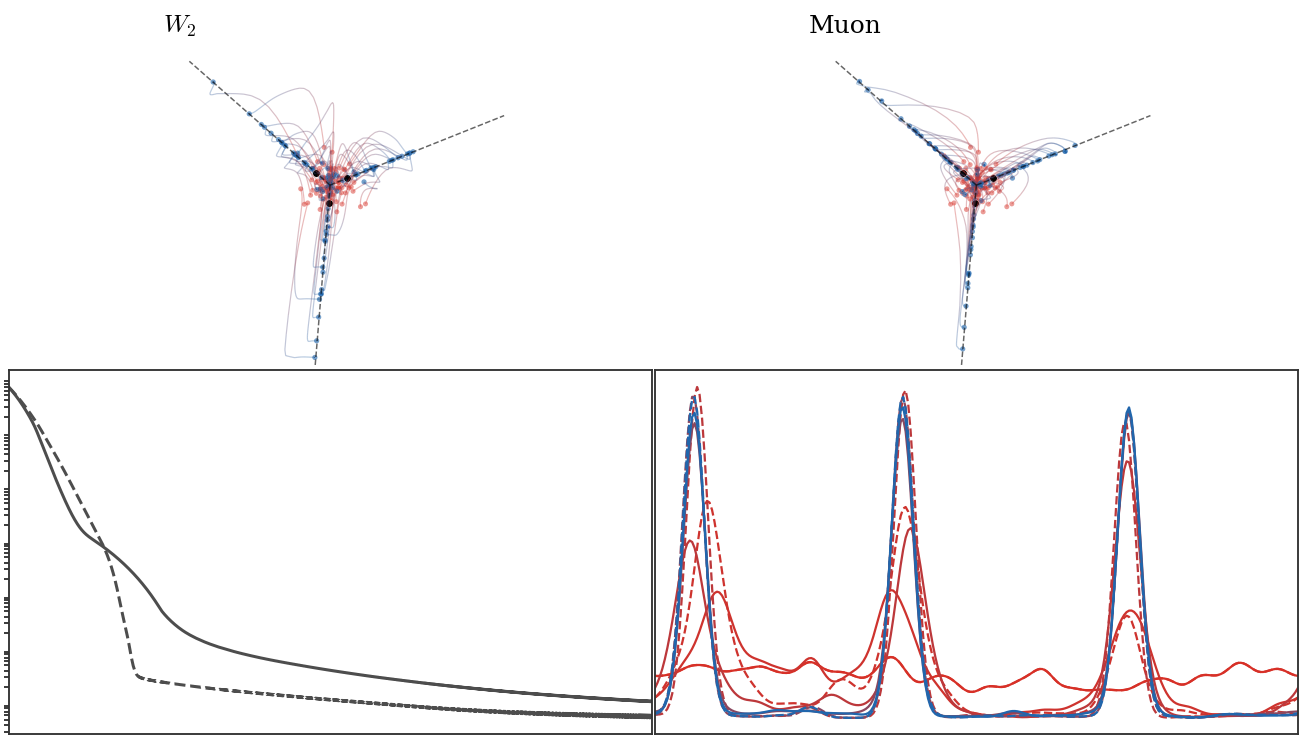

In [5]:
from IPython.display import Image, display
display(Image(filename=str(thumb_dir / f"{NAME}.png")))
